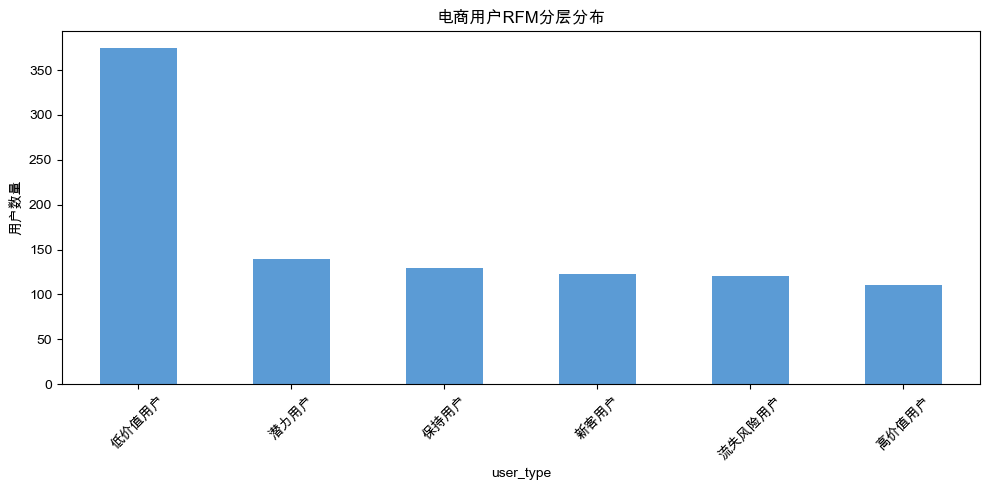

=== 电商用户 RFM 价值分层结果 ===
user_type
低价值用户     375
潜力用户      139
保持用户      129
新客用户      123
流失风险用户    120
高价值用户     110
Name: count, dtype: int64


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)
data = {
    'user_id': np.random.randint(10000, 99999, 1000),
    'order_date': pd.date_range('2024-01-01', periods=1000, freq='h'),
    'amount': np.random.uniform(50, 2000, 1000)
}
df = pd.DataFrame(data)
df = df.drop_duplicates(subset=['user_id', 'order_date'])

current_date = df['order_date'].max()
rfm = df.groupby('user_id').agg(
    R=('order_date', lambda x: (current_date - x.max()).days),
    F=('user_id', 'count'),
    M=('amount', 'sum')
)

rfm['R_score'] = pd.qcut(rfm['R'], 2, labels=[2, 1])
rfm['F_score'] = pd.qcut(rfm['F'].rank(method='first'), 2, labels=[1, 2])
rfm['M_score'] = pd.qcut(rfm['M'], 2, labels=[1, 2])

def rfm_classify(row):
    if row['R_score'] == 2 and row['F_score'] == 2 and row['M_score'] == 2:
        return '高价值用户'
    elif row['R_score'] == 1 and row['F_score'] == 2 and row['M_score'] == 2:
        return '保持用户'
    elif row['R_score'] == 2 and row['F_score'] == 1 and row['M_score'] == 2:
        return '潜力用户'
    elif row['R_score'] == 2 and row['F_score'] == 2 and row['M_score'] == 1:
        return '新客用户'
    elif row['R_score'] == 1 and row['F_score'] == 1 and row['M_score'] == 2:
        return '流失风险用户'
    else:
        return '低价值用户'

rfm['user_type'] = rfm.apply(rfm_classify, axis=1)
user_count = rfm['user_type'].value_counts()

user_count.plot(kind='bar', figsize=(10, 5), color='#5B9BD5')
plt.title('电商用户RFM分层分布')
plt.ylabel('用户数量')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("=== 电商用户 RFM 价值分层结果 ===")
print(user_count)